In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt
from sklearn.metrics import r2_score
from tqdm import tqdm

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir, 'src')))
from dataloadermaker import DataLoaderMaker
import vis_utils as vu
import probabilistic_utils as pu
from collections import defaultdict, Counter

USE_MACOS = True 
if USE_MACOS:
    pytensor.config.cxx = ""

In [3]:
fp_folder = '/Users/tplas/data/2025-06-16 moth data Natalie/'

Text(0.5, 1.0, 'Moth hatch observations per year in HV')

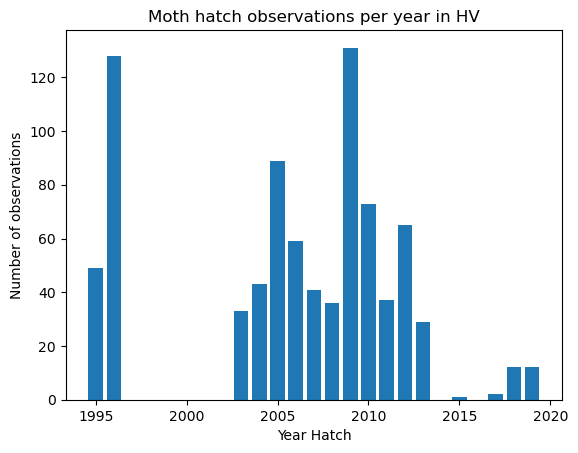

In [4]:
df_moth_raw_obs = pu.load_and_prep_moth_data(fp_path=os.path.join(fp_folder, '1994-2019_field-d50.csv'), location_list=['HV'])
tmp = Counter(df_moth_raw_obs['YearHatch'])
plt.bar(height=tmp.values(), x=tmp.keys())
plt.xlabel('Year Hatch')
plt.ylabel('Number of observations')
plt.title('Moth hatch observations per year in HV')

In [5]:
df_mo = pu.prep_moth_data_for_regression(dir_moth_data='/Users/tplas/data/2025-06-16 moth data Natalie/')
df_mo

/Users/tplas/repos/VeluweProtoDT/Py/src/dataloadermaker.py:34: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filePath)
/Users/tplas/repos/VeluweProtoDT/Py/src/probabilistic_utils.py:159: RuntimeWarning: invalid value encountered in floor_divide
  moth_cdf = np.arange(len(arr_doy)) // float(len(arr_doy) - 1)


,moth_cdf,date,temperature,season
0,0.0,1994-12-01 00:00:00+00:00,3.358087,1994-1995
1,0.0,1994-12-02 00:00:00+00:00,1.960794,1994-1995
2,0.0,1994-12-03 00:00:00+00:00,7.626090,1994-1995
3,0.0,1994-12-04 00:00:00+00:00,9.356979,1994-1995
4,0.0,1994-12-05 00:00:00+00:00,9.008084,1994-1995
...,...,...,...,...
3093,1.0,2019-05-27 00:00:00+00:00,14.090170,2018-2019
3094,1.0,2019-05-28 00:00:00+00:00,10.768054,2018-2019
3095,1.0,2019-05-29 00:00:00+00:00,12.626536,2018-2019
3096,1.0,2019-05-30 00:00:00+00:00,16.648355,2018-2019


No data provided -- using default data


/Users/tplas/repos/VeluweProtoDT/Py/src/dataloadermaker.py:34: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filePath)


Filtering data for locations: ['Hoge Veluwe']
182


/Users/tplas/repos/VeluweProtoDT/Py/src/dataloadermaker.py:34: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filePath)


182


/Users/tplas/repos/VeluweProtoDT/Py/src/probabilistic_utils.py:159: RuntimeWarning: invalid value encountered in floor_divide
  moth_cdf = np.arange(len(arr_doy)) // float(len(arr_doy) - 1)


<Axes: xlabel='date', ylabel='moth_cdf'>

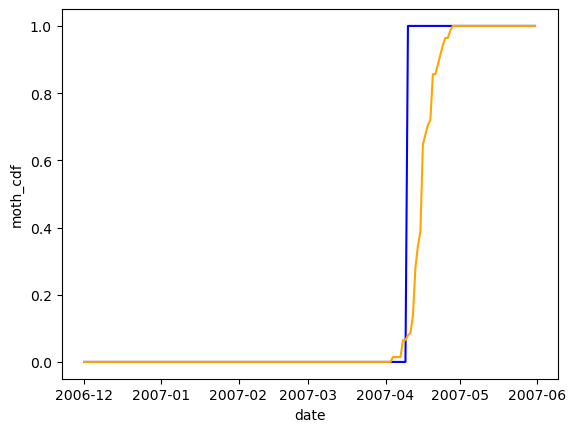

In [6]:
import seaborn as sns

s = '2006-2007'
df_bb = pu.prep_budburst_data_for_regression()
df_bb = df_bb[df_bb['season'] == s]
print(len(df_bb))

df_mo = pu.prep_moth_data_for_regression(dir_moth_data=fp_folder)
df_mo = df_mo[df_mo['season'] == s]
print(len(df_mo))

sns.lineplot(data=df_mo, x='date', y='moth_cdf', color='blue')
sns.lineplot(data=df_bb, x='date', y='bb_cdf', color='orange')

In [9]:
posterior_samples, df_train, df_test, model = pu.bayesian_inference(
            data_type='moth',
            mcmc_draw_samples=10,
            mcmc_tune_samples=10,
            mcmc_chains=8,
            infer_chilling=False,
            zoned_chilling=False,
            mcmc_cores=8,
            n_splits=3,
            split_seasons_traintest=0
    )

/Users/tplas/repos/VeluweProtoDT/Py/src/dataloadermaker.py:34: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filePath)
<string>:19: RuntimeWarning: invalid value encountered in floor_divide
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pymc/data.py:384: FutureWarning: Data is now always mutable. Specifying the `mutable` kwarg will raise an error in a future release
  warnings.warn(
Only 10 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Training seasons: ['2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012', '2012-2013', '2014-2015', '2016-2017', '2017-2018', '2018-2019'], test seasons: ['1994-1995', '1995-1996', '2002-2003', '2003-2004', '2004-2005']


Multiprocess sampling (8 chains in 8 jobs)
CompoundStep
>NUTS: [t_base_force, alpha, beta, sigma]
>Metropolis: [start_date]


Output()

/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pytensor/scalar/basic.py:3191: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pytensor/scalar/basic.py:3191: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pytensor/scalar/basic.py:3191: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pytensor/scalar/basic.py:3191: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pytensor/scalar/basic.py:3191: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pytensor/scalar/basic.py:3191: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pytensor/scalar/basic.py:3191:

/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Sampling 8 chains for 10 tune and 10 draw iterations (80 + 80 draws total) took 20 seconds.
The number of samples is too small to check convergence reliably.


In [10]:
posterior_samples

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
	> constant_data